# Temporal Analysis: Heat Stress Metrics Over Time

This notebook performs comprehensive temporal analysis of nighttime recovery, daytime heat, and VPD statistics across different time scales:

**Analysis Types:**
1. Seasonal patterns and cycles
2. Inter-annual trends
3. Decadal comparisons
4. Anomaly detection
5. Long-term climate trends
6. Seasonal decomposition
7. Calendar heatmaps
8. Year-over-year variability

**Time Periods:** 1984-2025 (41 years)
**Focus States:** TX, OK, KS, NE (cattle-producing states)
**Seasons:** DJF (Winter), MAM (Spring), JJA (Summer), SON (Fall)

In [1]:
# Standard imports
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path
from datetime import datetime
from scipy import stats
from scipy.signal import detrend
import warnings
warnings.filterwarnings('ignore')

# Plotting configuration
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 12
sns.set_style('whitegrid')
sns.set_palette('husl')

print("Imports complete!")

Imports complete!


In [ ]:
# Configuration
DATA_DIR = Path('../..')  # Up two levels from notebooks/03_analysis/ to research/
NIGHTTIME_DIR = DATA_DIR / 'processed_nighttime_recovery'
DAYTIME_DIR = DATA_DIR / 'processed_daytime_heat'
VPD_DIR = DATA_DIR / 'processed_vpd'
MASK_FILE = DATA_DIR / 'masks/region_mask.nc'
OUTPUT_DIR = Path('../../figures/temporal')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Focus states (Regions 4 & 6: major cattle-producing states)
# Note: IDs are from region_mask.nc (alphabetical order, not standard FIPS)
FOCUS_STATES = {
    'Alabama': 1,
    'Arizona': 3,
    'Florida': 8,
    'Georgia': 9,
    'Kentucky': 15,
    'Louisiana': 16,
    'Mississippi': 23,
    'New Mexico': 30,
    'North Carolina': 25,
    'Oklahoma': 34,
    'South Carolina': 38,
    'Tennessee': 40,
    'Texas': 41
}

# Seasons
SEASONS = {
    'Winter': [12, 1, 2],
    'Spring': [3, 4, 5],
    'Summer': [6, 7, 8],
    'Fall': [9, 10, 11]
}

print(f"Data directory: {DATA_DIR.resolve()}")
print(f"Output directory: {OUTPUT_DIR.resolve()}")

In [ ]:
# Load state mask
ds_mask = xr.open_dataset(MASK_FILE)
state_mask = ds_mask.state_mask.load()  # Load data into memory before closing
lat = ds_mask.lat.values
lon = ds_mask.lon.values
ds_mask.close()

print(f"State mask shape: {state_mask.shape}")
print(f"Lat range: [{lat.min():.1f}, {lat.max():.1f}]")
print(f"Lon range: [{lon.min():.1f}, {lon.max():.1f}]")

In [4]:
def load_monthly_data(data_dir, year_start=1984, year_end=2025):
    """Load all monthly data files for a given metric."""
    files = sorted(data_dir.glob('*.nc'))
    datasets = []
    
    for f in files:
        # Parse year/month from filename
        year_month = f.stem.split('_')[-1]
        year = int(year_month[:4])
        
        if year_start <= year <= year_end:
            datasets.append(xr.open_dataset(f))
    
    if datasets:
        return xr.concat(datasets, dim='time')
    return None

def compute_state_mean(data, state_id):
    """Compute spatial mean for a specific state.
    
    Converts timedelta64[ns] to float hours if needed.
    """
    mask = state_mask == state_id
    masked_data = data.where(mask)
    state_mean = masked_data.mean(dim=['lat', 'lon'])
    
    # Convert timedelta to hours if data is stored as timedelta
    if state_mean.dtype.kind == 'm':  # 'm' = timedelta
        # Convert nanoseconds to hours: divide by (3600 * 10^9)
        state_mean = state_mean / np.timedelta64(1, 'h')
        state_mean = state_mean.astype(np.float64)
    
    return state_mean

def mann_kendall_test(x):
    """Perform Mann-Kendall trend test."""
    n = len(x)
    s = 0
    for i in range(n-1):
        for j in range(i+1, n):
            s += np.sign(x[j] - x[i])
    
    var_s = n * (n-1) * (2*n+5) / 18
    z = s / np.sqrt(var_s) if var_s > 0 else 0
    p_value = 2 * (1 - stats.norm.cdf(abs(z)))
    
    return {'z': z, 'p': p_value, 'trend': 'increasing' if z > 0 else 'decreasing'}

def get_season(month):
    """Get season name from month number."""
    for season, months in SEASONS.items():
        if month in months:
            return season
    return None

print("Helper functions defined!")

Helper functions defined!


## Load and Prepare Data

In [5]:
# Load all datasets
print("Loading nighttime recovery data...")
ds_night = load_monthly_data(NIGHTTIME_DIR)

print("Loading daytime heat data...")
ds_day = load_monthly_data(DAYTIME_DIR)

print("Loading VPD data...")
ds_vpd = load_monthly_data(VPD_DIR)

print(f"\nData loaded:")
print(f"  Nighttime: {ds_night.time.shape[0]} days ({ds_night.time.dt.year.min().values}-{ds_night.time.dt.year.max().values})")
print(f"  Daytime: {ds_day.time.shape[0]} days")
print(f"  VPD: {ds_vpd.time.shape[0]} days")

Loading nighttime recovery data...
Loading daytime heat data...
Loading VPD data...

Data loaded:
  Nighttime: 15341 days (1984-2025)
  Daytime: 15341 days
  VPD: 15341 days


## Plot 1: Seasonal Cycle by State

Shows the typical seasonal pattern for each state across all years.

NameError: name 'state_mask' is not defined

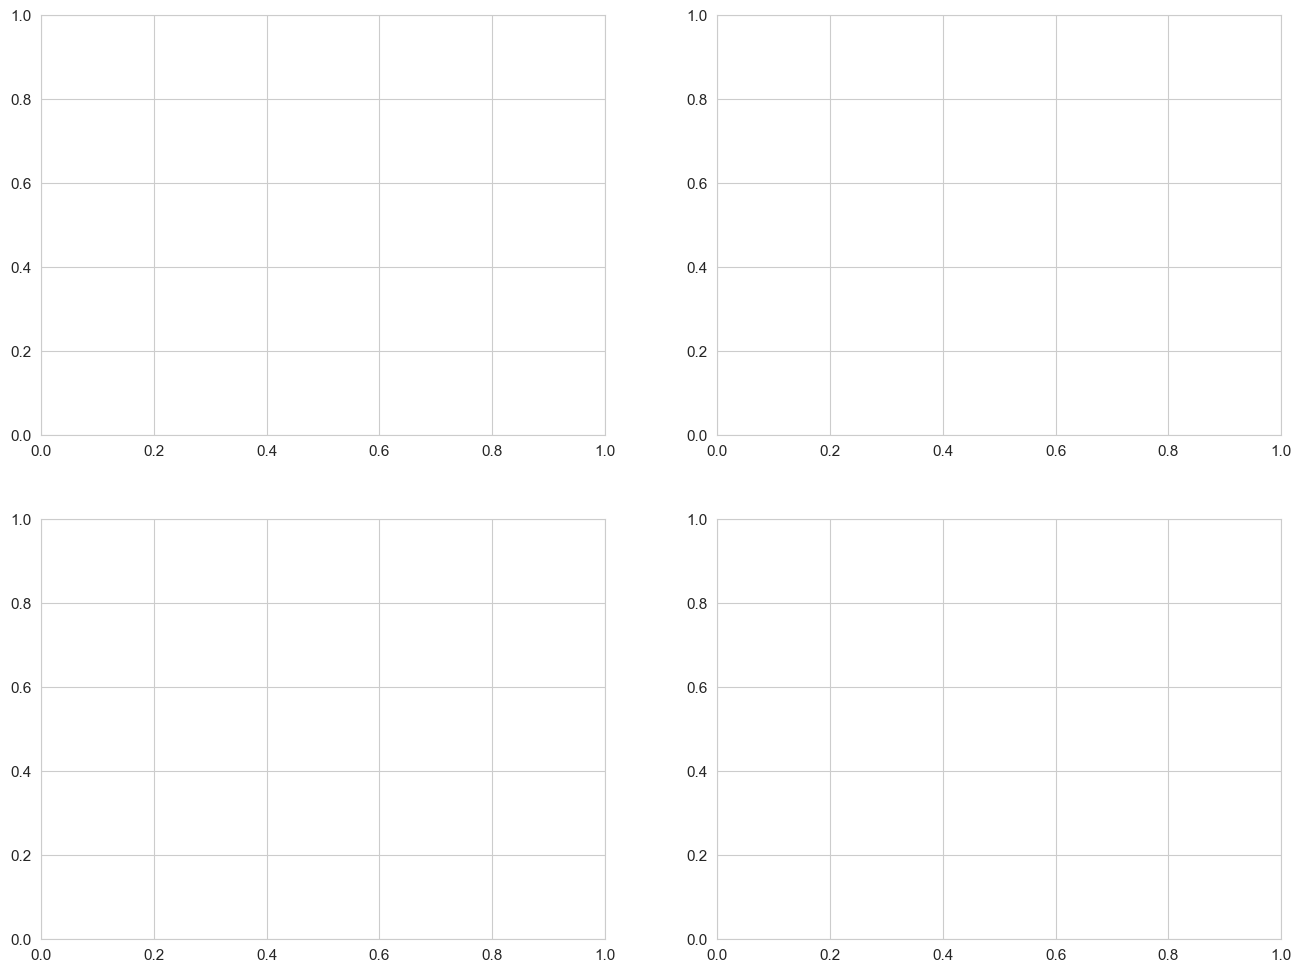

In [6]:
# Compute monthly climatology for each state
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

metrics = [
    ('hours_above_24', 'Nighttime Hours Above 24°C (Poor Recovery)', ds_night),
    ('hours_above_30', 'Daytime Hours Above 30°C (Very Hot)', ds_day),
    ('vpd_mean', 'Afternoon Mean VPD (kPa)', ds_vpd),
    ('hours_below_0', 'Nighttime Hours Below 0°C (Freezing)', ds_night)
]

for idx, (metric, title, ds) in enumerate(metrics):
    ax = axes[idx]
    
    for state_name, state_id in list(FOCUS_STATES.items()): 
        # Compute state mean
        state_data = compute_state_mean(ds[metric], state_id)
        
        # Group by month and compute climatological mean
        monthly_clim = state_data.groupby('time.month').mean()
        
        ax.plot(monthly_clim.month, monthly_clim.values, marker='o', linewidth=2, label=state_name)
    
    ax.set_xlabel('Month')
    ax.set_ylabel(title.split('(')[0].strip())
    ax.set_title(title, fontweight='bold')
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D'])
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / '01_seasonal_cycles.png', dpi=300, bbox_inches='tight')
plt.show()
print("Plot 1 saved!")

## Plot 2: Annual Trends (1984-2025)

Long-term trends showing climate change impacts.

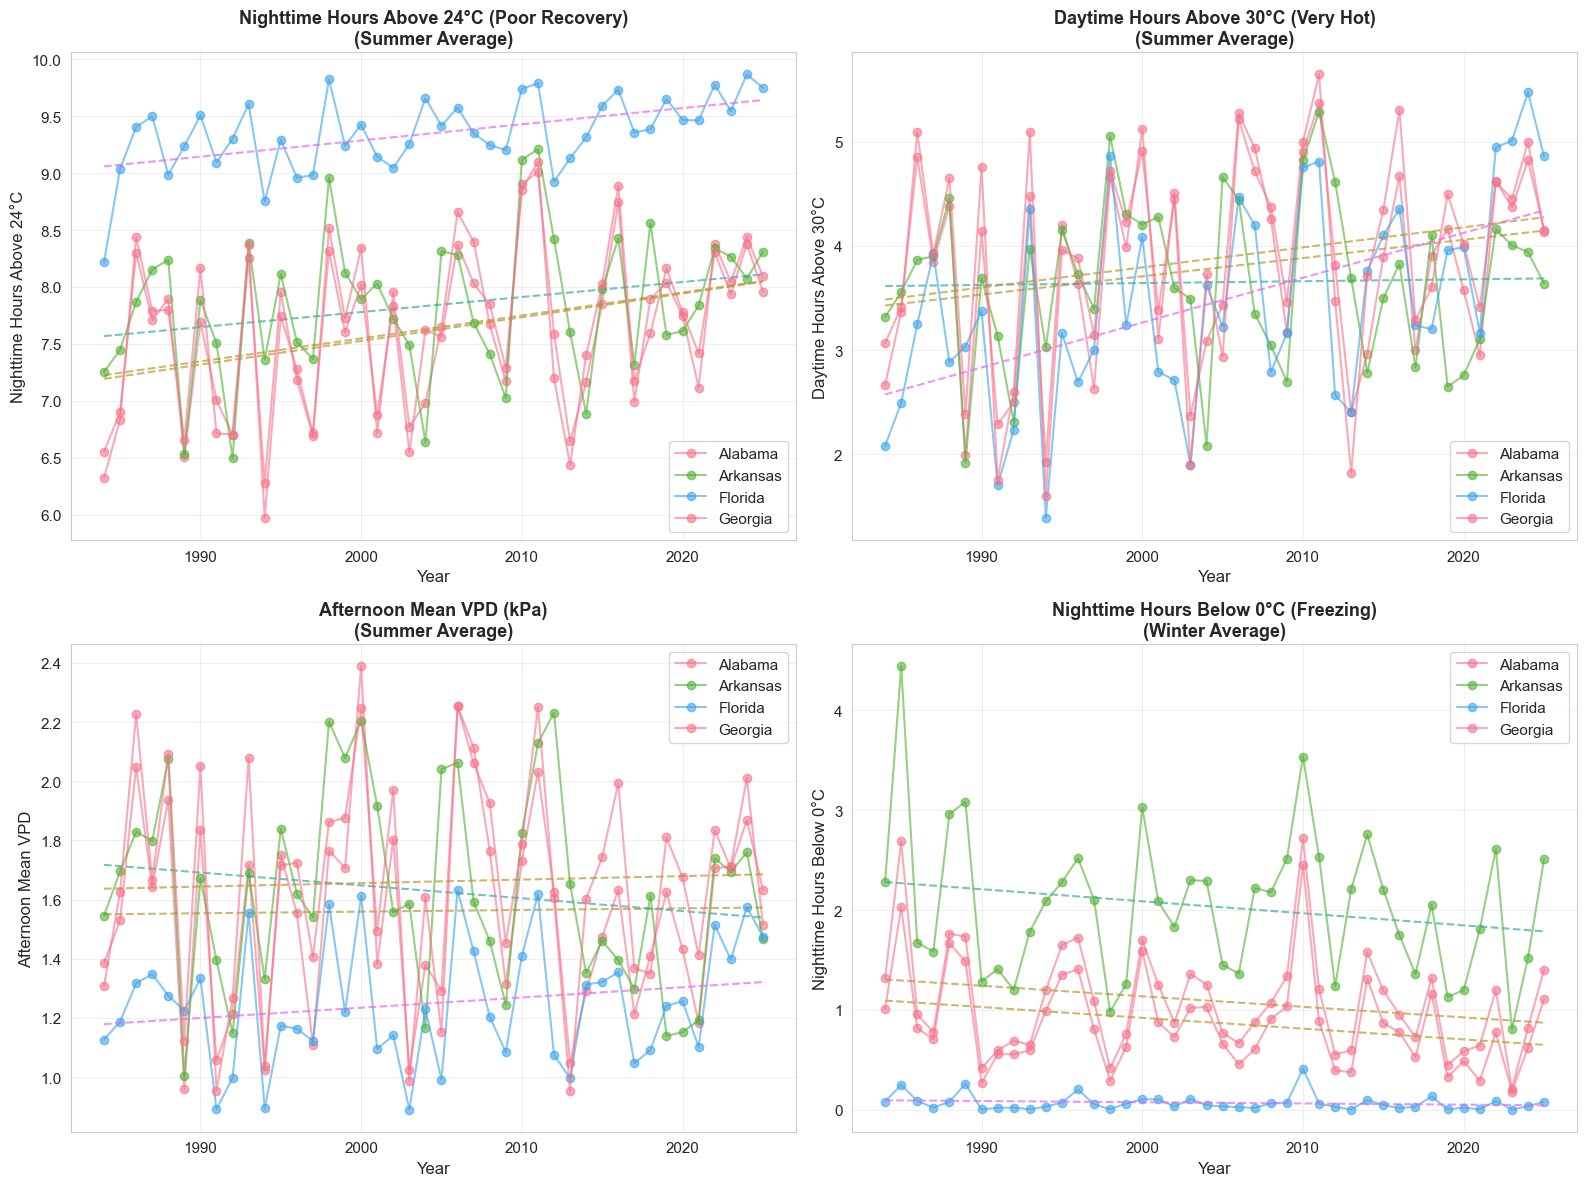

Plot 2 saved!


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

# Focus on summer months (JJA) for heat metrics
for idx, (metric, title, ds) in enumerate(metrics):
    ax = axes[idx]
    
    for state_name, state_id in list(FOCUS_STATES.items())[:4]:
        # Compute state mean
        state_data = compute_state_mean(ds[metric], state_id)
        
        # Compute annual mean (summer months for heat metrics)
        if 'above' in metric or 'vpd' in metric:
            # Summer average
            summer_data = state_data.where(state_data.time.dt.month.isin([6, 7, 8]), drop=True)
            annual_mean = summer_data.groupby('time.year').mean()
        else:
            # Winter average for cold metrics
            winter_data = state_data.where(state_data.time.dt.month.isin([12, 1, 2]), drop=True)
            annual_mean = winter_data.groupby('time.year').mean()
        
        # Extract years and values with explicit type conversion
        years = annual_mean['year'].values.astype(np.int64)
        values = annual_mean.values.astype(np.float64)
        
        # Plot with trend line
        ax.plot(years, values, marker='o', alpha=0.6, label=state_name)
        
        # Add linear trend
        z = np.polyfit(years, values, 1)
        p = np.poly1d(z)
        ax.plot(years, p(years), '--', alpha=0.7, linewidth=1.5)
    
    ax.set_xlabel('Year')
    ax.set_ylabel(title.split('(')[0].strip())
    season_label = 'Summer' if 'above' in metric or 'vpd' in metric else 'Winter'
    ax.set_title(f"{title}\n({season_label} Average)", fontweight='bold')
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / '02_annual_trends.png', dpi=300, bbox_inches='tight')
plt.show()
print("Plot 2 saved!")

## Plot 3: Decadal Comparison Boxplots

Compare distributions across decades to identify shifts.

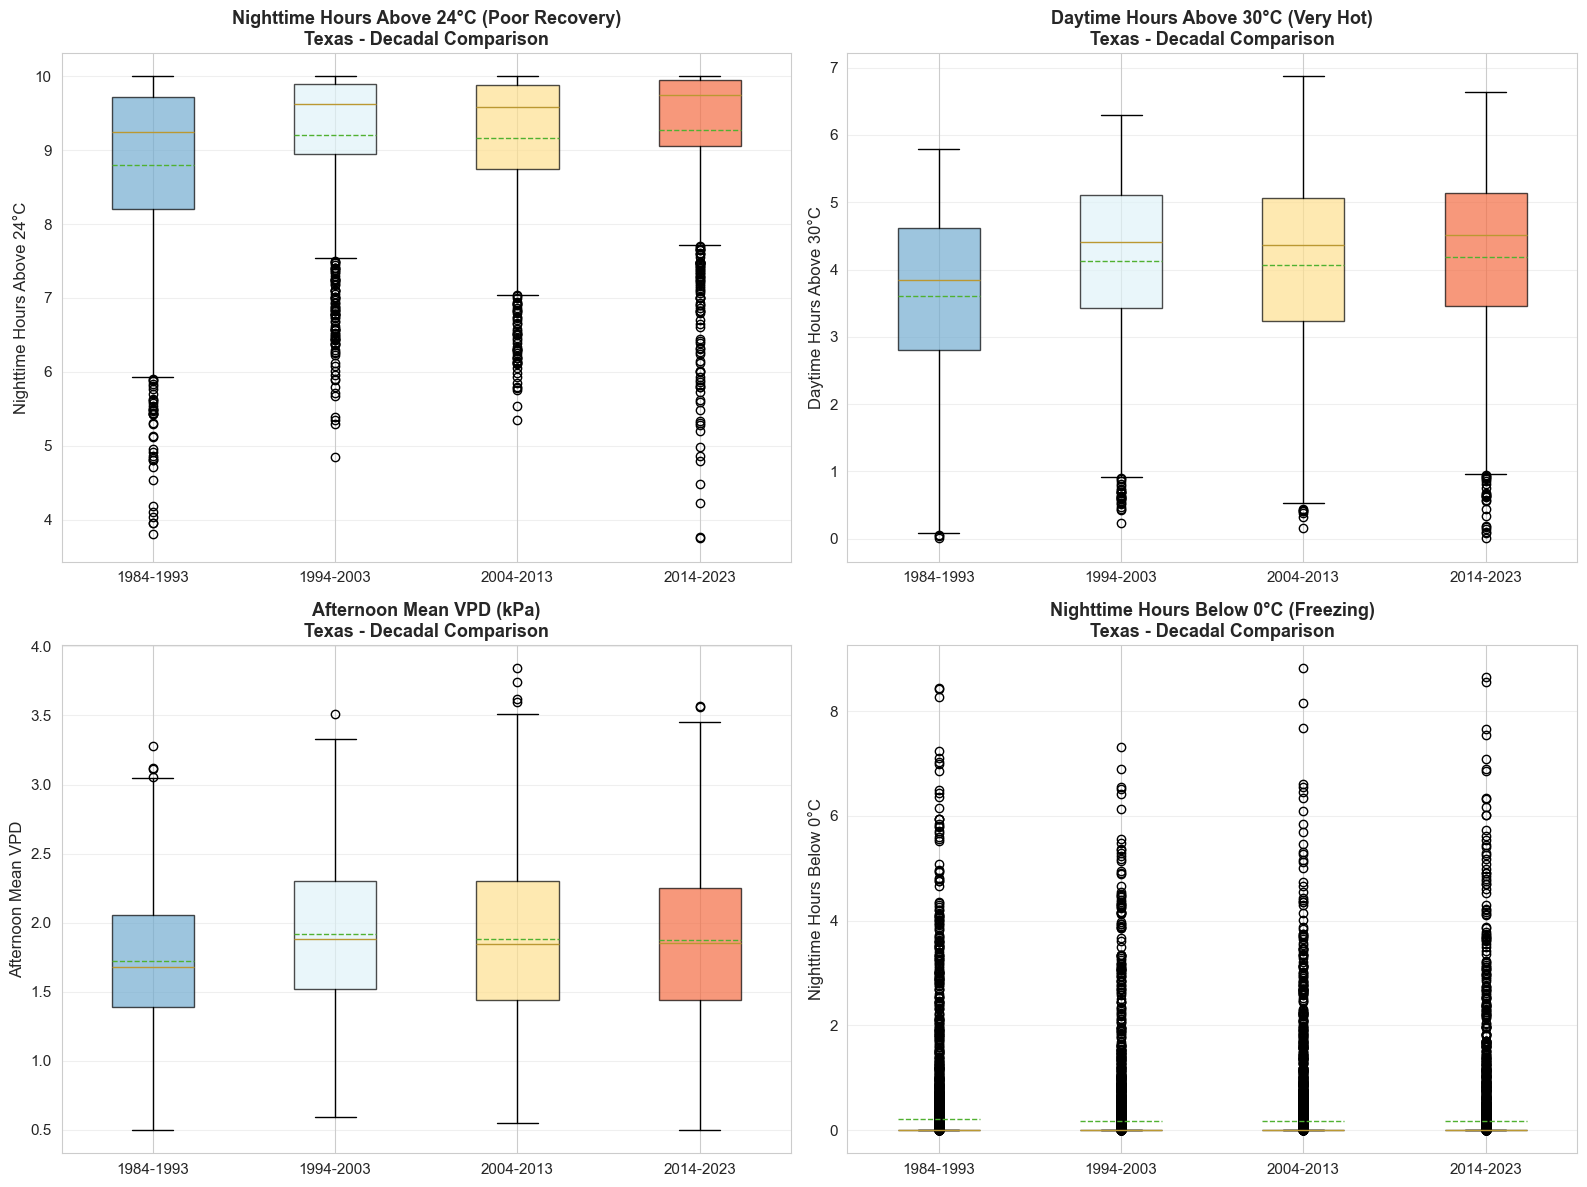

Plot 3 saved!


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

# Define decades
decades = [
    ('1984-1993', 1984, 1993),
    ('1994-2003', 1994, 2003),
    ('2004-2013', 2004, 2013),
    ('2014-2023', 2014, 2023)
]

state_name = 'Texas'  # Focus on Texas
state_id = FOCUS_STATES[state_name]

for idx, (metric, title, ds) in enumerate(metrics):
    ax = axes[idx]
    
    # Compute state mean
    state_data = compute_state_mean(ds[metric], state_id)
    
    # Filter for summer months
    if 'above' in metric or 'vpd' in metric:
        state_data = state_data.where(state_data.time.dt.month.isin([6, 7, 8]), drop=True)
    
    # Prepare data for boxplot
    data_by_decade = []
    labels = []
    
    for decade_label, year_start, year_end in decades:
        decade_data = state_data.where(
            (state_data.time.dt.year >= year_start) & (state_data.time.dt.year <= year_end),
            drop=True
        )
        # Explicitly convert to float64 and filter out NaN values
        decade_values = decade_data.values.astype(np.float64)
        decade_values = decade_values[~np.isnan(decade_values)]
        data_by_decade.append(decade_values)
        labels.append(decade_label)
    
    # Create boxplot
    bp = ax.boxplot(data_by_decade, labels=labels, patch_artist=True, 
                     showmeans=True, meanline=True)
    
    # Color boxes
    colors = plt.cm.RdYlBu_r(np.linspace(0.2, 0.8, len(decades)))
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    ax.set_ylabel(title.split('(')[0].strip())
    ax.set_title(f"{title}\n{state_name} - Decadal Comparison", fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '03_decadal_boxplots.png', dpi=300, bbox_inches='tight')
plt.show()
print("Plot 3 saved!")

## Plot 4: Calendar Heatmap (Recent Year)

Daily values visualized as a calendar for detailed pattern inspection.

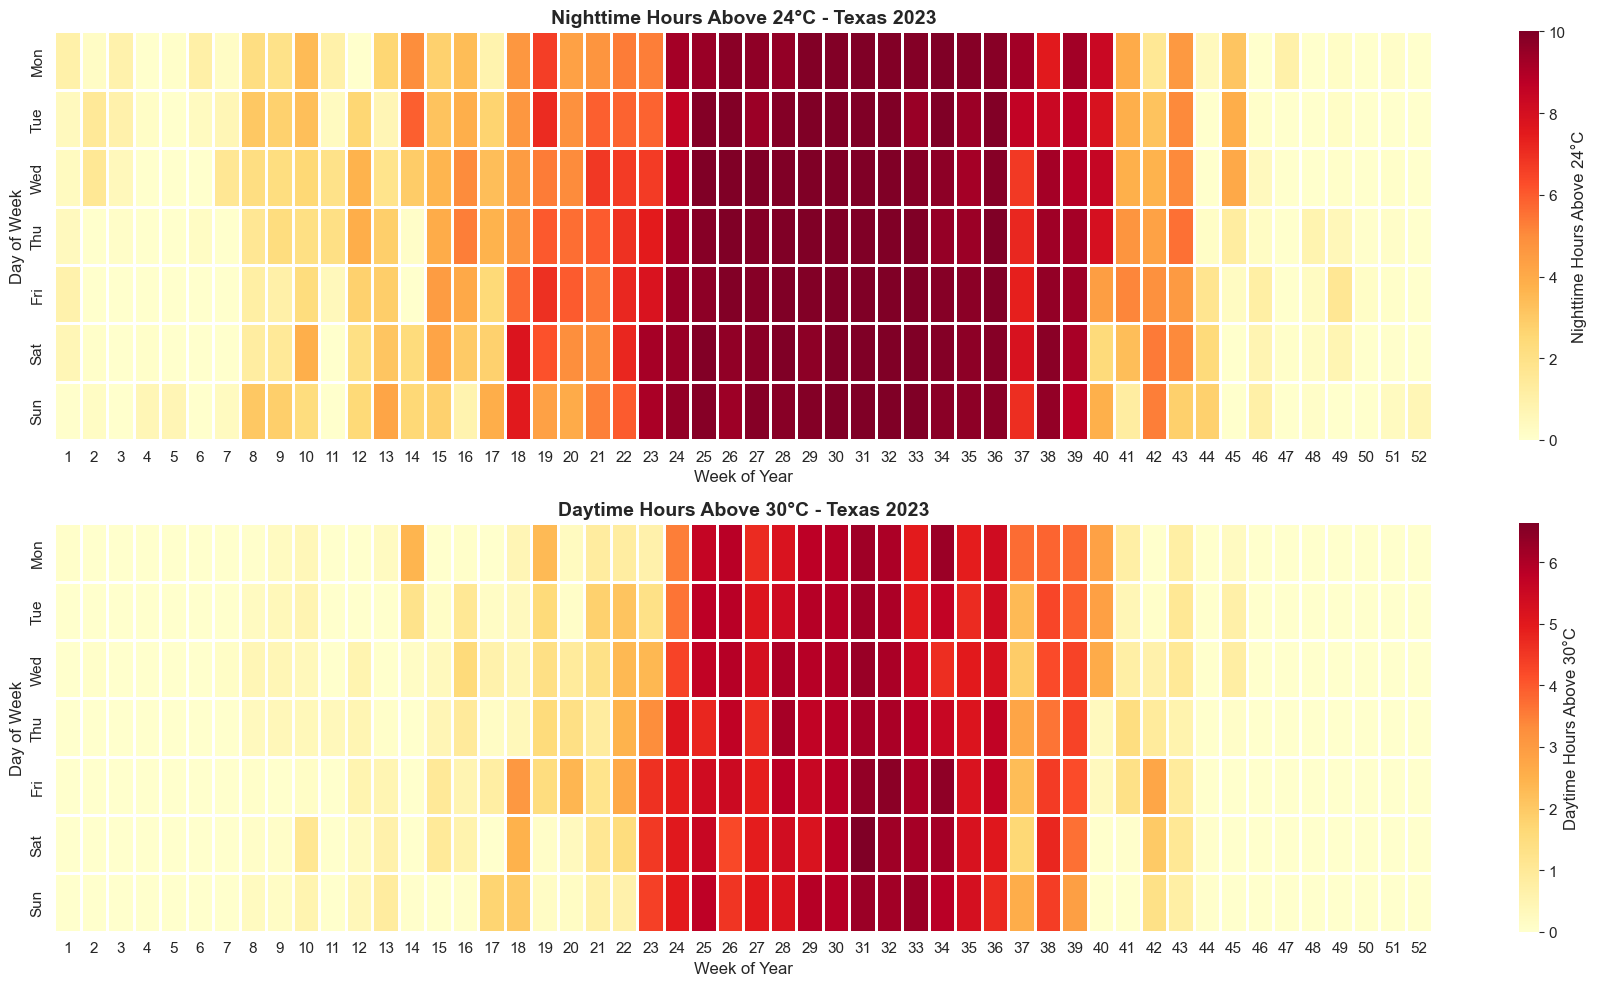

Plot 4 saved!


In [9]:
# Focus on 2023 for Texas
year = 2023
state_name = 'Texas'
state_id = FOCUS_STATES[state_name]

fig, axes = plt.subplots(2, 1, figsize=(18, 10))

metrics_calendar = [
    ('hours_above_24', 'Nighttime Hours Above 24°C', ds_night),
    ('hours_above_30', 'Daytime Hours Above 30°C', ds_day)
]

for idx, (metric, title, ds) in enumerate(metrics_calendar):
    ax = axes[idx]
    
    # Get data for specific year
    state_data = compute_state_mean(ds[metric], state_id)
    year_data = state_data.sel(time=str(year))
    
    # Create calendar matrix
    df = pd.DataFrame({
        'date': pd.to_datetime(year_data.time.values),
        'value': year_data.values.astype(np.float64)
    })
    df['week'] = df['date'].dt.isocalendar().week
    df['dow'] = df['date'].dt.dayofweek
    df['month'] = df['date'].dt.month
    
    # Pivot to create calendar (use pivot_table to handle any duplicate entries)
    calendar_data = df.pivot_table(index='dow', columns='week', values='value', aggfunc='mean')
    
    # Plot heatmap
    sns.heatmap(calendar_data, ax=ax, cmap='YlOrRd', cbar_kws={'label': title},
                linewidths=1, linecolor='white', square=False)
    
    ax.set_xlabel('Week of Year')
    ax.set_ylabel('Day of Week')
    ax.set_yticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
    ax.set_title(f"{title} - {state_name} {year}", fontweight='bold', fontsize=14)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / f'04_calendar_heatmap_{year}.png', dpi=300, bbox_inches='tight')
plt.show()
print("Plot 4 saved!")

## Plot 5: Anomaly Time Series

Departures from long-term average highlighting unusual years.

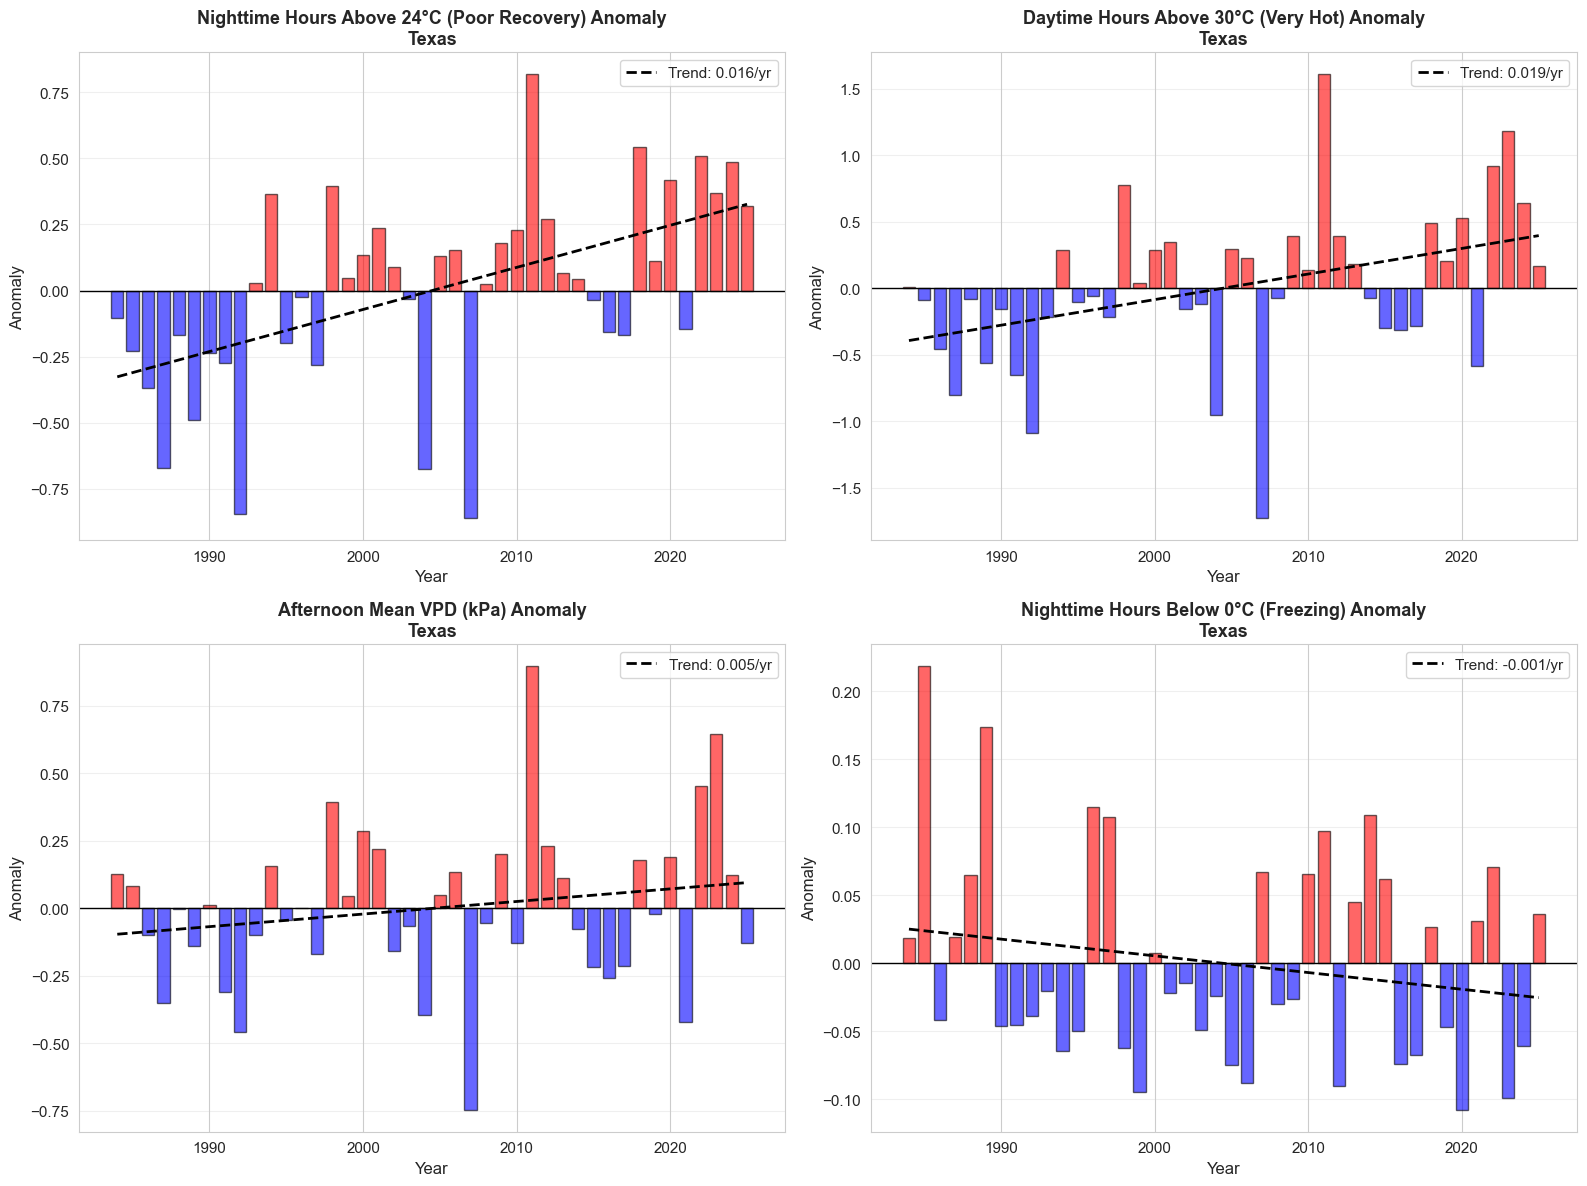

Plot 5 saved!


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

state_name = 'Texas'
state_id = FOCUS_STATES[state_name]

for idx, (metric, title, ds) in enumerate(metrics):
    ax = axes[idx]
    
    # Compute state mean
    state_data = compute_state_mean(ds[metric], state_id)
    
    # Filter for appropriate season
    if 'above' in metric or 'vpd' in metric:
        state_data = state_data.where(state_data.time.dt.month.isin([6, 7, 8]), drop=True)
    
    # Compute annual mean
    annual_mean = state_data.groupby('time.year').mean()
    
    # Compute anomaly (departure from long-term mean)
    climatology = annual_mean.mean()
    anomaly = annual_mean - climatology
    
    # Extract years and values with explicit type conversion
    years = anomaly['year'].values.astype(np.int64)
    values = anomaly.values.astype(np.float64)
    
    # Create bar plot with colors
    colors = ['red' if v > 0 else 'blue' for v in values]
    ax.bar(years, values, color=colors, alpha=0.6, edgecolor='black')
    ax.axhline(0, color='black', linewidth=1, linestyle='-')
    
    # Add trend line
    z = np.polyfit(years, values, 1)
    p = np.poly1d(z)
    ax.plot(years, p(years), 'k--', linewidth=2, label=f'Trend: {z[0]:.3f}/yr')
    
    ax.set_xlabel('Year')
    ax.set_ylabel('Anomaly')
    ax.set_title(f"{title} Anomaly\n{state_name}", fontweight='bold')
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / '05_anomaly_timeseries.png', dpi=300, bbox_inches='tight')
plt.show()
print("Plot 5 saved!")

## Plot 6: Seasonal Decomposition

Decompose time series into trend, seasonal, and residual components.

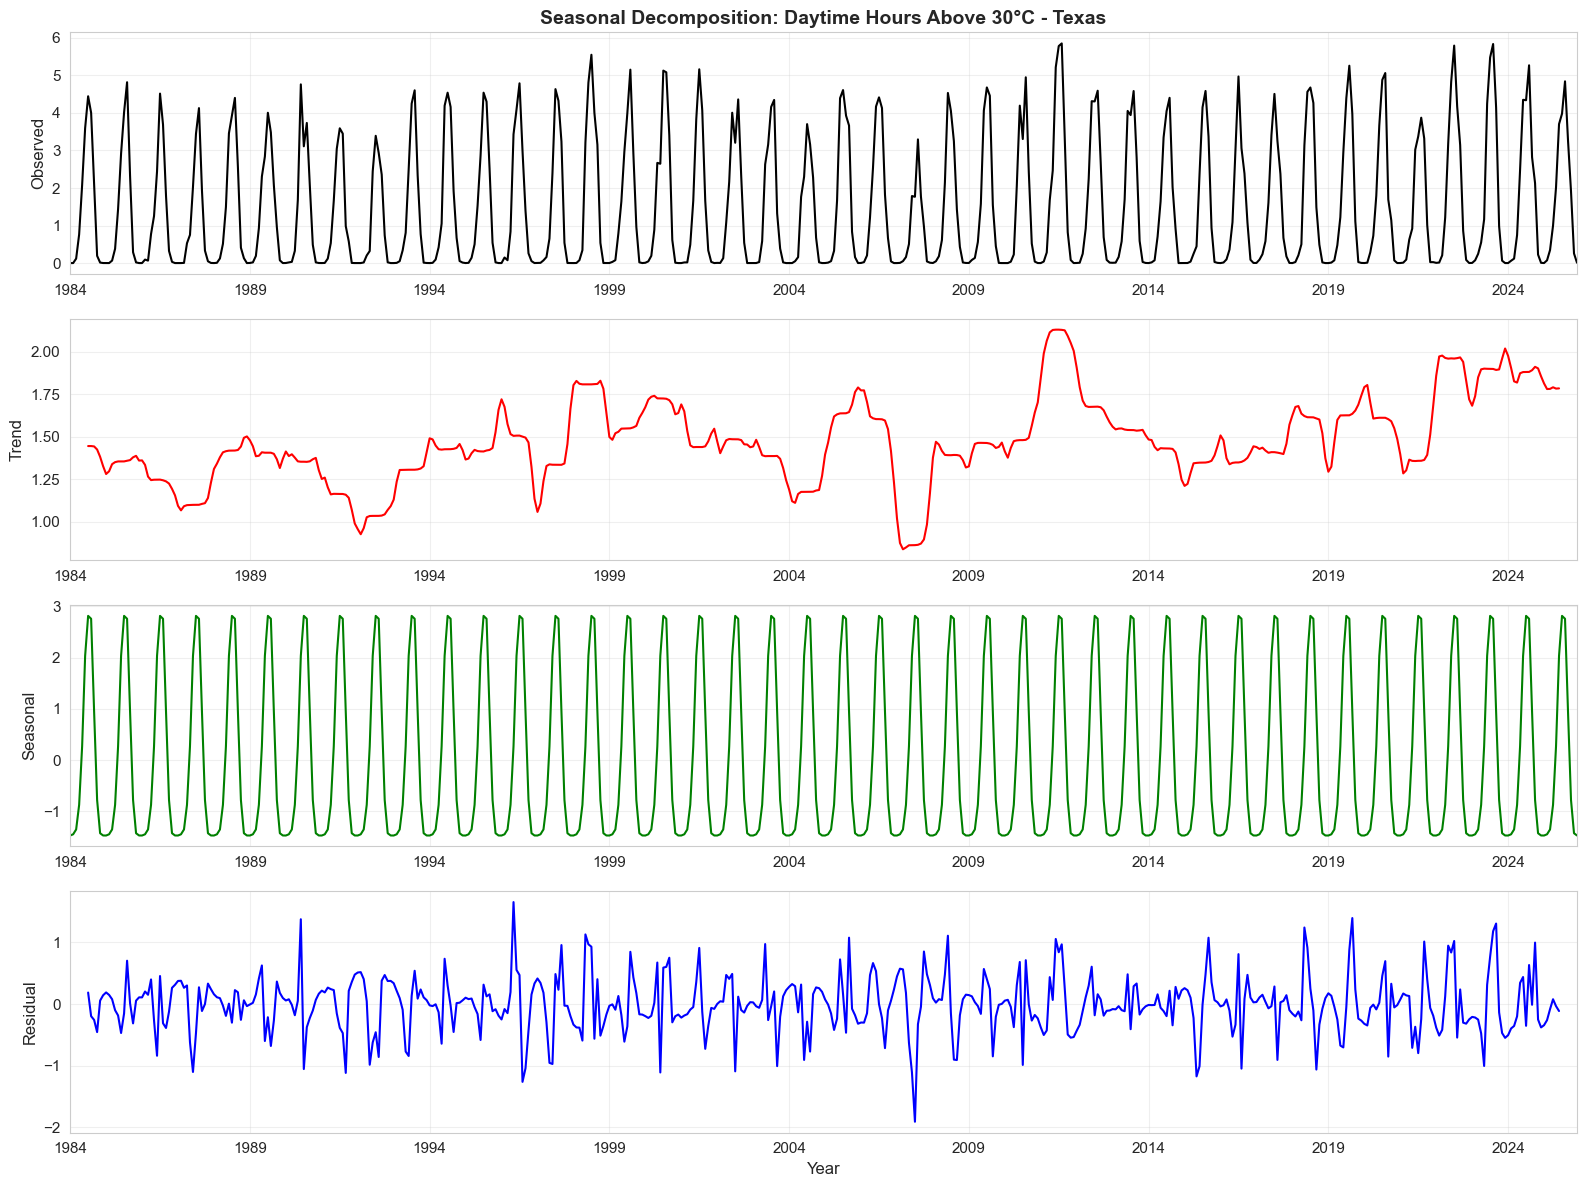

Plot 6 saved!


In [11]:
from statsmodels.tsa.seasonal import seasonal_decompose

state_name = 'Texas'
state_id = FOCUS_STATES[state_name]
metric = 'hours_above_30'

# Compute state mean
state_data = compute_state_mean(ds_day[metric], state_id)

# Resample to monthly data
monthly_data = state_data.resample(time='M').mean()

# Create DataFrame for statsmodels
df = pd.DataFrame({
    'value': monthly_data.values
}, index=pd.to_datetime(monthly_data.time.values))

# Perform seasonal decomposition
decomposition = seasonal_decompose(df['value'], model='additive', period=12)

# Plot decomposition
fig, axes = plt.subplots(4, 1, figsize=(16, 12))

decomposition.observed.plot(ax=axes[0], color='black')
axes[0].set_ylabel('Observed')
axes[0].set_title(f'Seasonal Decomposition: Daytime Hours Above 30°C - {state_name}', fontweight='bold', fontsize=14)
axes[0].grid(True, alpha=0.3)

decomposition.trend.plot(ax=axes[1], color='red')
axes[1].set_ylabel('Trend')
axes[1].grid(True, alpha=0.3)

decomposition.seasonal.plot(ax=axes[2], color='green')
axes[2].set_ylabel('Seasonal')
axes[2].grid(True, alpha=0.3)

decomposition.resid.plot(ax=axes[3], color='blue')
axes[3].set_ylabel('Residual')
axes[3].set_xlabel('Year')
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / '06_seasonal_decomposition.png', dpi=300, bbox_inches='tight')
plt.show()
print("Plot 6 saved!")

## Plot 7: Multi-State Comparison Across Seasons

Compare how different states respond across seasons.

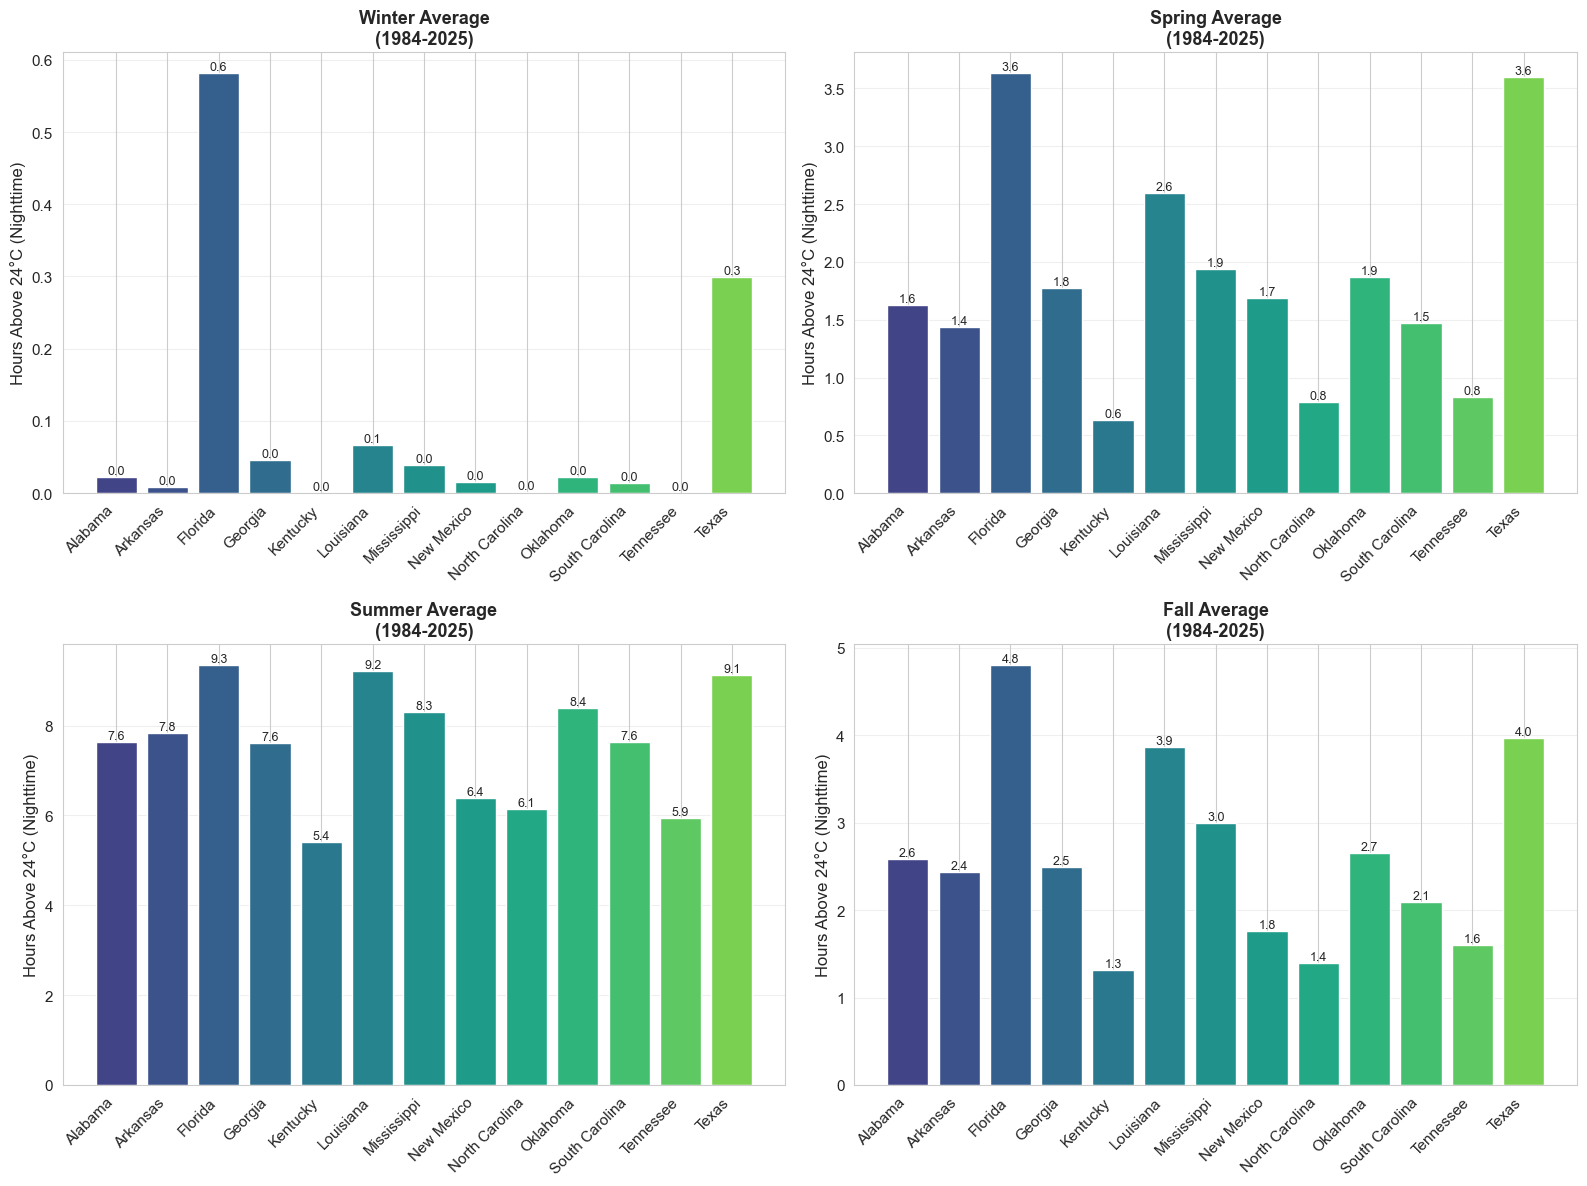

Plot 7 saved!


In [12]:
metric = 'hours_above_24'
ds = ds_night

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, (season_name, months) in enumerate(SEASONS.items()):
    ax = axes[idx]
    
    state_means = {}
    
    for state_name, state_id in FOCUS_STATES.items():
        # Compute state mean
        state_data = compute_state_mean(ds[metric], state_id)
        
        # Filter for season
        season_data = state_data.where(state_data.time.dt.month.isin(months), drop=True)
        
        # Compute annual mean for this season
        annual_seasonal_mean = season_data.groupby('time.year').mean()
        
        state_means[state_name] = float(annual_seasonal_mean.mean().values)
    
    # Create bar plot
    states = list(state_means.keys())
    values = list(state_means.values())
    
    bars = ax.bar(range(len(states)), values, color=plt.cm.viridis(np.linspace(0.2, 0.8, len(states))))
    ax.set_xticks(range(len(states)))
    ax.set_xticklabels(states, rotation=45, ha='right')
    ax.set_ylabel('Hours Above 24°C (Nighttime)')
    ax.set_title(f'{season_name} Average\n(1984-2025)', fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / '07_seasonal_state_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("Plot 7 saved!")

## Plot 8: Year-over-Year Variability

Coefficient of variation showing which metrics are most variable.

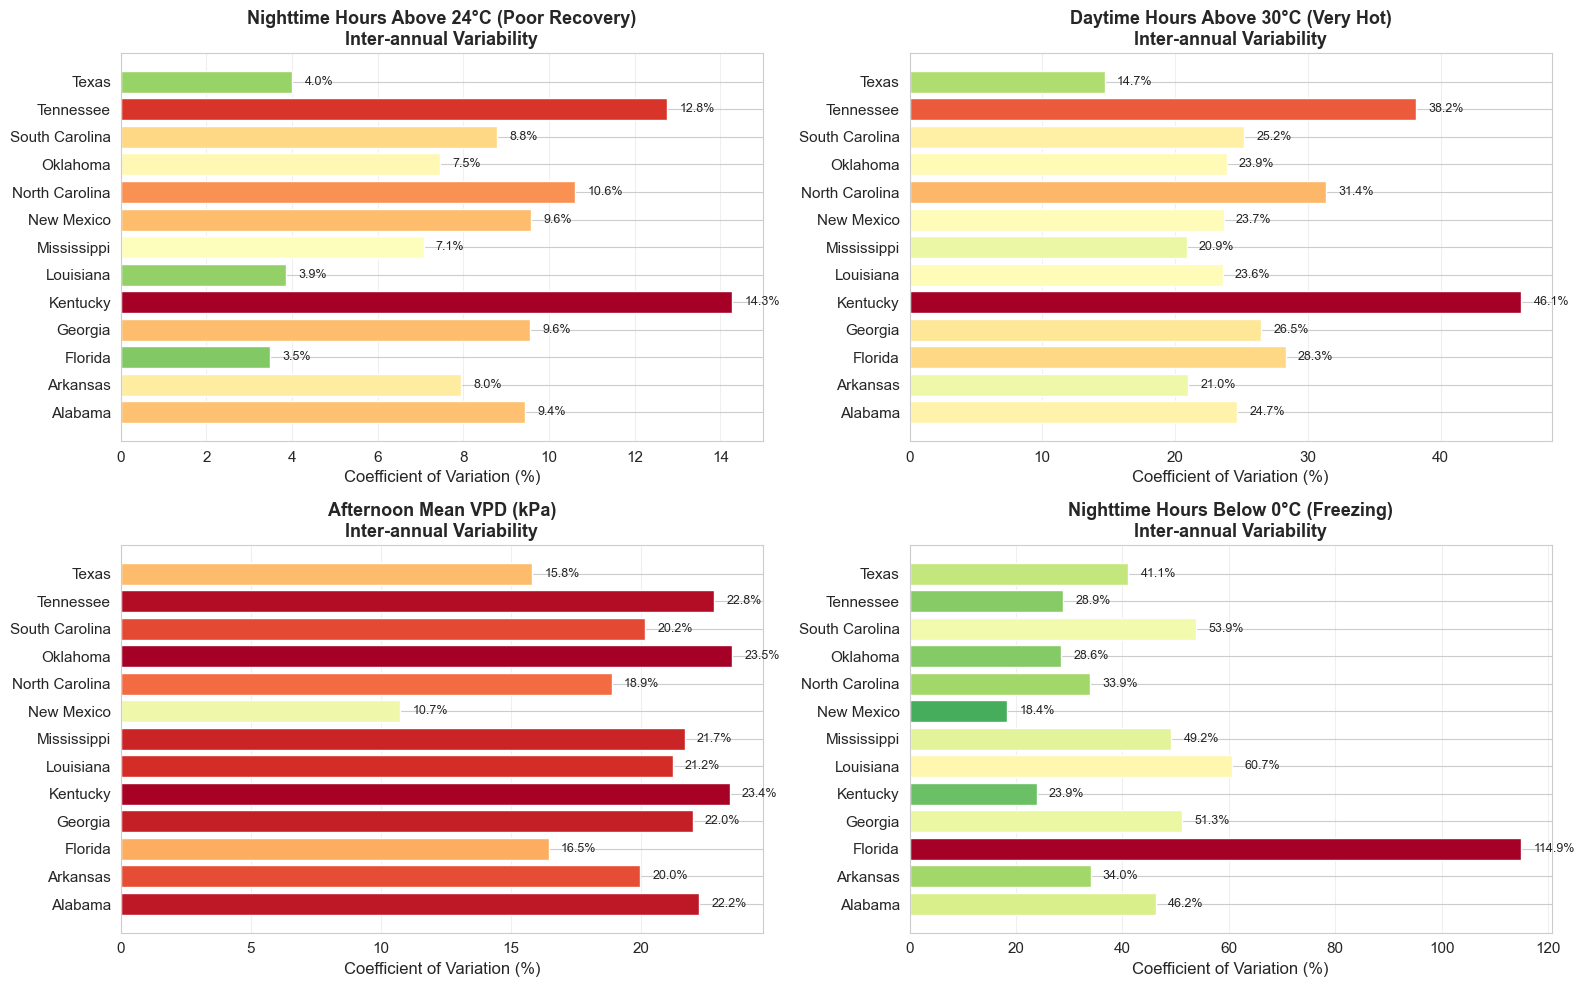

Plot 8 saved!

=== Temporal Analysis Complete ===
8 plots saved to /Users/klesinger/Library/CloudStorage/GoogleDrive-kdl0040@uah.edu/My Drive/VEDA/Stories/livestock_and_heat/research/tests/figures/temporal


In [13]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for idx, (metric, title, ds) in enumerate(metrics):
    ax = axes[idx]
    
    cv_by_state = {}
    
    for state_name, state_id in FOCUS_STATES.items():
        # Compute state mean
        state_data = compute_state_mean(ds[metric], state_id)
        
        # Filter for appropriate season
        if 'above' in metric or 'vpd' in metric:
            state_data = state_data.where(state_data.time.dt.month.isin([6, 7, 8]), drop=True)
        
        # Compute annual mean
        annual_mean = state_data.groupby('time.year').mean()
        
        # Compute coefficient of variation
        cv = float((annual_mean.std() / annual_mean.mean()).values) * 100
        cv_by_state[state_name] = cv
    
    # Create bar plot
    states = list(cv_by_state.keys())
    values = list(cv_by_state.values())
    
    bars = ax.barh(range(len(states)), values, color=plt.cm.RdYlGn_r(np.array(values)/max(values)))
    ax.set_yticks(range(len(states)))
    ax.set_yticklabels(states)
    ax.set_xlabel('Coefficient of Variation (%)')
    ax.set_title(f'{title}\nInter-annual Variability', fontweight='bold')
    ax.grid(True, alpha=0.3, axis='x')
    
    # Add value labels
    for i, (bar, val) in enumerate(zip(bars, values)):
        ax.text(val + max(values)*0.02, i, f'{val:.1f}%',
                ha='left', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / '08_variability_by_state.png', dpi=300, bbox_inches='tight')
plt.show()
print("Plot 8 saved!")
print("\n=== Temporal Analysis Complete ===")
print(f"8 plots saved to {OUTPUT_DIR.resolve()}")

## Plot 9: Seasonal Expansion - First and Last Hot Night

Shows when hot nights begin and end each year, and how this timing is changing.

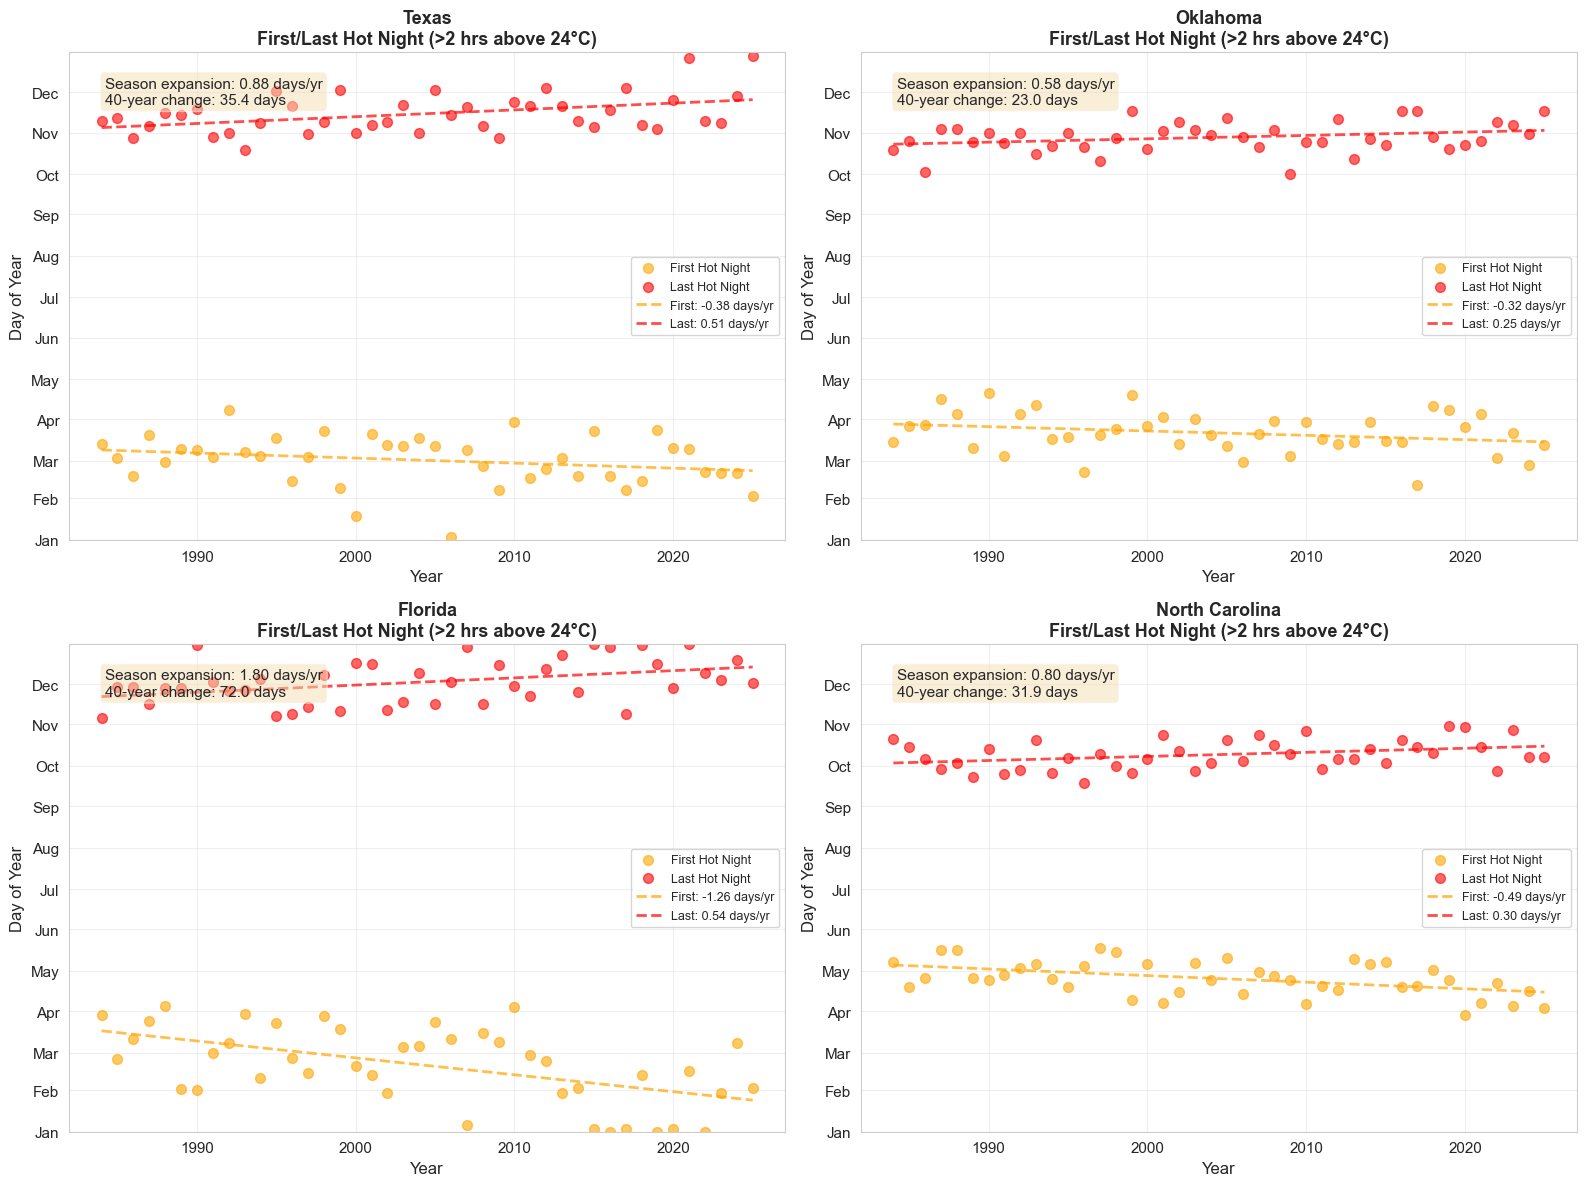

Plot 9 saved!


In [14]:
# Analyze seasonal expansion: first and last occurrence of hot nights
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

# Focus states for comparison
focus_states_subset = {
    'Texas': 41,
    'Oklahoma': 34,
    'Florida': 8,
    'North Carolina': 25
}

threshold = 24  # Temperature threshold in °C

for idx, (state_name, state_id) in enumerate(focus_states_subset.items()):
    ax = axes[idx]
    
    # Compute state mean
    state_data = compute_state_mean(ds_night['hours_above_24'], state_id)
    
    # Find first and last day of year with hot nights (>2 hours above threshold)
    first_days = []
    last_days = []
    years = []
    
    for year in range(state_data.time.dt.year.min().values, state_data.time.dt.year.max().values + 1):
        year_data = state_data.where(state_data.time.dt.year == year, drop=True)
        
        if len(year_data) > 0:
            # Find days with significant heat stress (>2 hours)
            hot_days = year_data.where(year_data > 2, drop=True)
            
            if len(hot_days) > 0:
                # Get day of year
                doy = hot_days.time.dt.dayofyear.values
                
                first_days.append(int(doy.min()))
                last_days.append(int(doy.max()))
                years.append(year)
    
    years = np.array(years)
    first_days = np.array(first_days)
    last_days = np.array(last_days)
    season_length = last_days - first_days
    
    # Plot first and last occurrence
    ax.scatter(years, first_days, alpha=0.6, s=50, label='First Hot Night', color='orange')
    ax.scatter(years, last_days, alpha=0.6, s=50, label='Last Hot Night', color='red')
    
    # Add trend lines
    if len(years) > 10:
        z_first = np.polyfit(years, first_days, 1)
        z_last = np.polyfit(years, last_days, 1)
        p_first = np.poly1d(z_first)
        p_last = np.poly1d(z_last)
        
        ax.plot(years, p_first(years), '--', alpha=0.7, linewidth=2, color='orange',
                label=f'First: {z_first[0]:.2f} days/yr')
        ax.plot(years, p_last(years), '--', alpha=0.7, linewidth=2, color='red',
                label=f'Last: {z_last[0]:.2f} days/yr')
        
        # Calculate season expansion
        expansion_rate = z_last[0] - z_first[0]
        expansion_40yr = expansion_rate * 40
        
        ax.text(0.05, 0.95, f'Season expansion: {expansion_rate:.2f} days/yr\n40-year change: {expansion_40yr:.1f} days',
                transform=ax.transAxes, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    # Add month labels
    month_days = [1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335]
    month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    ax.set_yticks(month_days)
    ax.set_yticklabels(month_names)
    
    ax.set_xlabel('Year')
    ax.set_ylabel('Day of Year')
    ax.set_title(f'{state_name}\nFirst/Last Hot Night (>2 hrs above {threshold}°C)', fontweight='bold')
    ax.legend(loc='center right', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_ylim([1, 365])

plt.tight_layout()
plt.savefig(OUTPUT_DIR / '09_seasonal_expansion_timing.png', dpi=300, bbox_inches='tight')
plt.show()
print("Plot 9 saved!")

## Plot 10: Monthly Frequency Changes by Decade

Shows how the frequency of hot nights in each month has changed across decades.

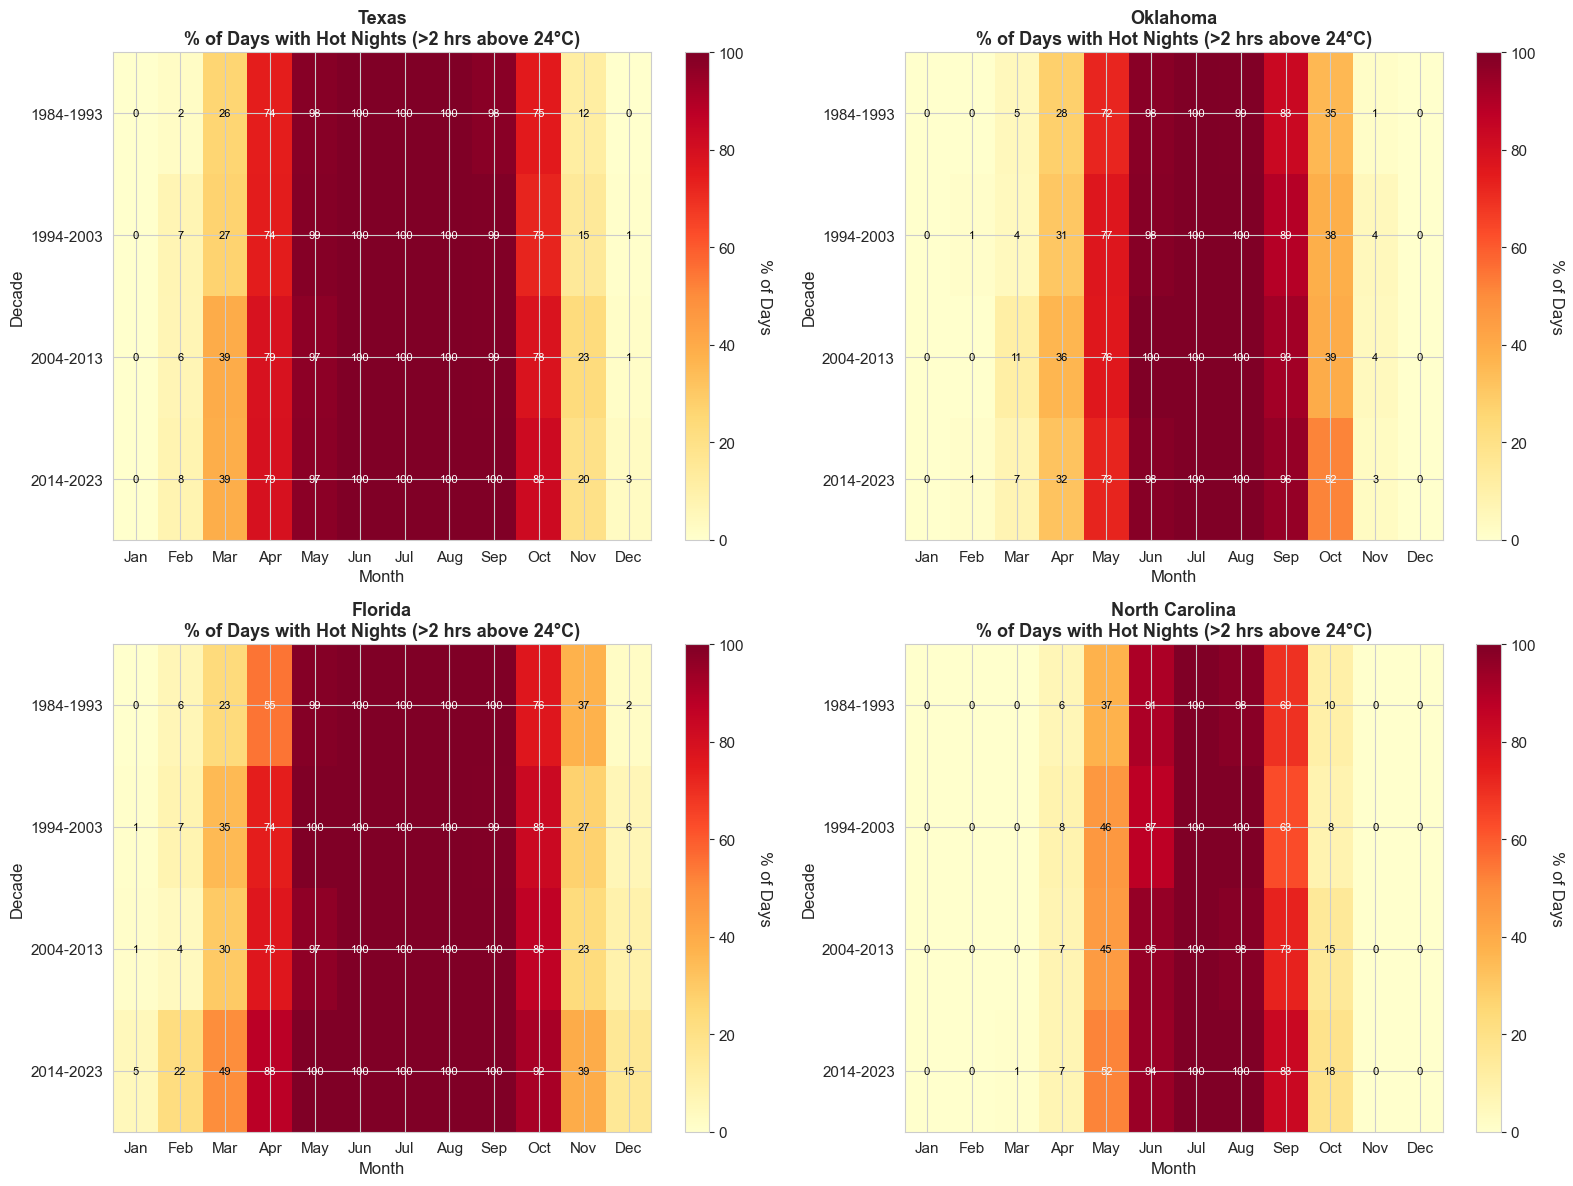

Plot 10 saved!

=== Seasonal Expansion Analysis Complete ===
These plots show how the hot night season is expanding over time.


In [15]:
# Monthly frequency changes by decade
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

decades_def = [
    ('1984-1993', 1984, 1993),
    ('1994-2003', 1994, 2003),
    ('2004-2013', 2004, 2013),
    ('2014-2023', 2014, 2023)
]

for idx, (state_name, state_id) in enumerate(focus_states_subset.items()):
    ax = axes[idx]
    
    # Compute state mean
    state_data = compute_state_mean(ds_night['hours_above_24'], state_id)
    
    # Compute frequency by month and decade
    monthly_freq = np.zeros((len(decades_def), 12))
    
    for decade_idx, (decade_name, year_start, year_end) in enumerate(decades_def):
        decade_data = state_data.where(
            (state_data.time.dt.year >= year_start) & (state_data.time.dt.year <= year_end),
            drop=True
        )
        
        for month in range(1, 13):
            month_data = decade_data.where(decade_data.time.dt.month == month, drop=True)
            # Percentage of days with >2 hours above threshold
            if len(month_data) > 0:
                hot_days = (month_data > 2).sum().values
                total_days = len(month_data)
                monthly_freq[decade_idx, month-1] = (hot_days / total_days * 100) if total_days > 0 else 0
    
    # Create heatmap
    im = ax.imshow(monthly_freq, aspect='auto', cmap='YlOrRd', vmin=0, vmax=100)
    
    # Set ticks
    ax.set_xticks(range(12))
    ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
    ax.set_yticks(range(len(decades_def)))
    ax.set_yticklabels([d[0] for d in decades_def])
    
    # Add values as text
    for i in range(len(decades_def)):
        for j in range(12):
            text = ax.text(j, i, f'{monthly_freq[i, j]:.0f}',
                          ha='center', va='center', color='black' if monthly_freq[i, j] < 50 else 'white',
                          fontsize=8)
    
    ax.set_title(f'{state_name}\n% of Days with Hot Nights (>2 hrs above {threshold}°C)', fontweight='bold')
    ax.set_xlabel('Month')
    ax.set_ylabel('Decade')
    
    # Add colorbar
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('% of Days', rotation=270, labelpad=20)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / '10_seasonal_expansion_monthly.png', dpi=300, bbox_inches='tight')
plt.show()
print("Plot 10 saved!")
print("\n=== Seasonal Expansion Analysis Complete ===")
print("These plots show how the hot night season is expanding over time.")

## Plot 11: VPD Trends by Month

Shows how afternoon VPD is changing in each month - VPD often shows stronger climate signals than temperature alone.

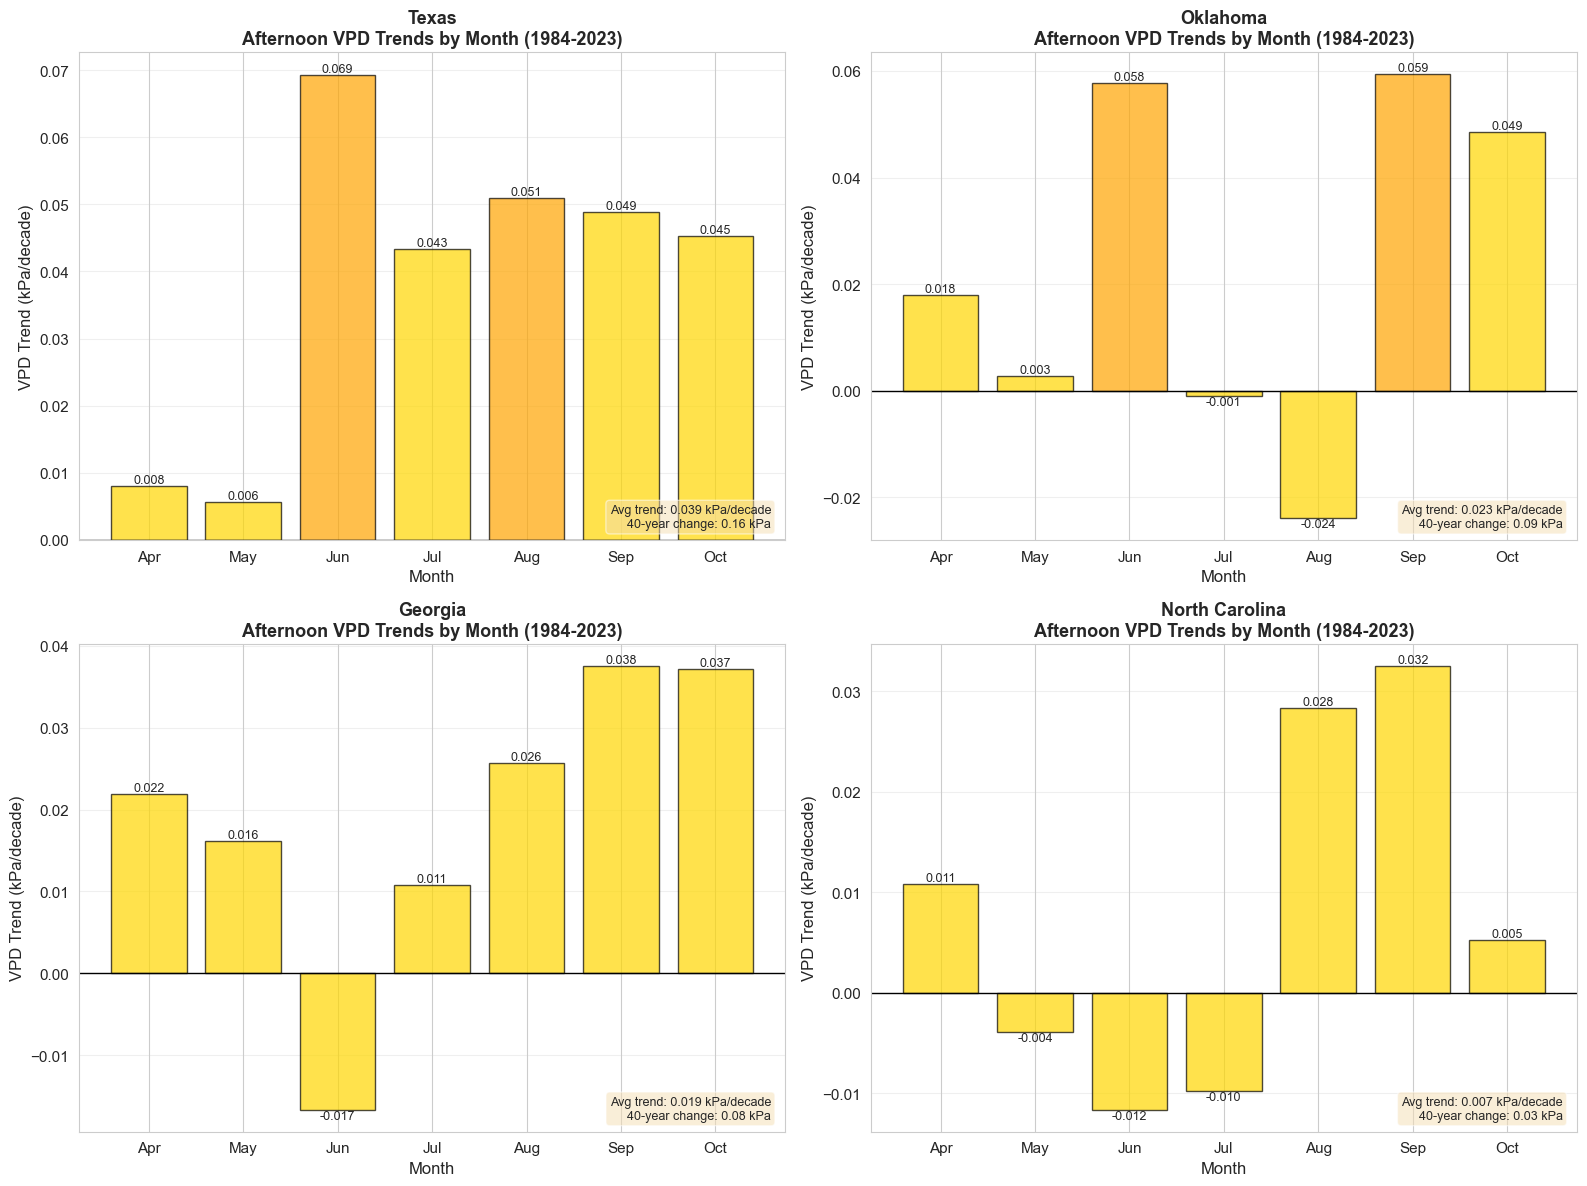

Plot 11 saved!


In [16]:
# VPD trends by month showing stronger climate signals
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

focus_states_vpd = {
    'Texas': 41,
    'Oklahoma': 34,
    'Georgia': 9,
    'North Carolina': 25
}

for idx, (state_name, state_id) in enumerate(focus_states_vpd.items()):
    ax = axes[idx]
    
    # Compute state mean for VPD
    state_data = compute_state_mean(ds_vpd['vpd_mean'], state_id)
    
    # Analyze trends by month (focus on growing season: Apr-Oct)
    months_to_analyze = [4, 5, 6, 7, 8, 9, 10]
    month_names_short = ['Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct']
    
    trends = []
    month_labels = []
    colors_list = []
    
    for month in months_to_analyze:
        # Filter for this month
        month_data = state_data.where(state_data.time.dt.month == month, drop=True)
        
        # Group by year
        annual_means = []
        years = []
        
        for year in range(1984, 2024):
            year_data = month_data.where(month_data.time.dt.year == year, drop=True)
            if len(year_data) > 10:  # Need sufficient data
                years.append(year)
                annual_means.append(float(year_data.mean().values))
        
        if len(years) > 20:
            # Compute trend
            z = np.polyfit(years, annual_means, 1)
            trend_per_decade = z[0] * 10  # Convert to per decade
            trends.append(trend_per_decade)
            month_labels.append(month_names_short[months_to_analyze.index(month)])
            
            # Color by magnitude
            colors_list.append('darkred' if trend_per_decade > 0.1 else 'orange' if trend_per_decade > 0.05 else 'gold')
    
    # Create bar plot of trends
    bars = ax.bar(range(len(trends)), trends, color=colors_list, edgecolor='black', alpha=0.7)
    ax.set_xticks(range(len(trends)))
    ax.set_xticklabels(month_labels)
    ax.axhline(0, color='black', linewidth=1, linestyle='-')
    ax.set_ylabel('VPD Trend (kPa/decade)')
    ax.set_xlabel('Month')
    ax.set_title(f'{state_name}\nAfternoon VPD Trends by Month (1984-2023)', fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for i, (bar, val) in enumerate(zip(bars, trends)):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{val:.3f}',
                ha='center', va='bottom' if val > 0 else 'top', fontsize=9)
    
    # Add context box
    avg_trend = np.mean(trends)
    total_40yr = avg_trend * 4
    ax.text(0.98, 0.02, f'Avg trend: {avg_trend:.3f} kPa/decade\n40-year change: {total_40yr:.2f} kPa',
            transform=ax.transAxes, verticalalignment='bottom', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5), fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / '11_vpd_trends_monthly.png', dpi=300, bbox_inches='tight')
plt.show()
print("Plot 11 saved!")

## Plot 12: Extreme VPD Days - Frequency Changes

Shows changes in frequency of extreme VPD days (>3.0 kPa), which stress crops and livestock.

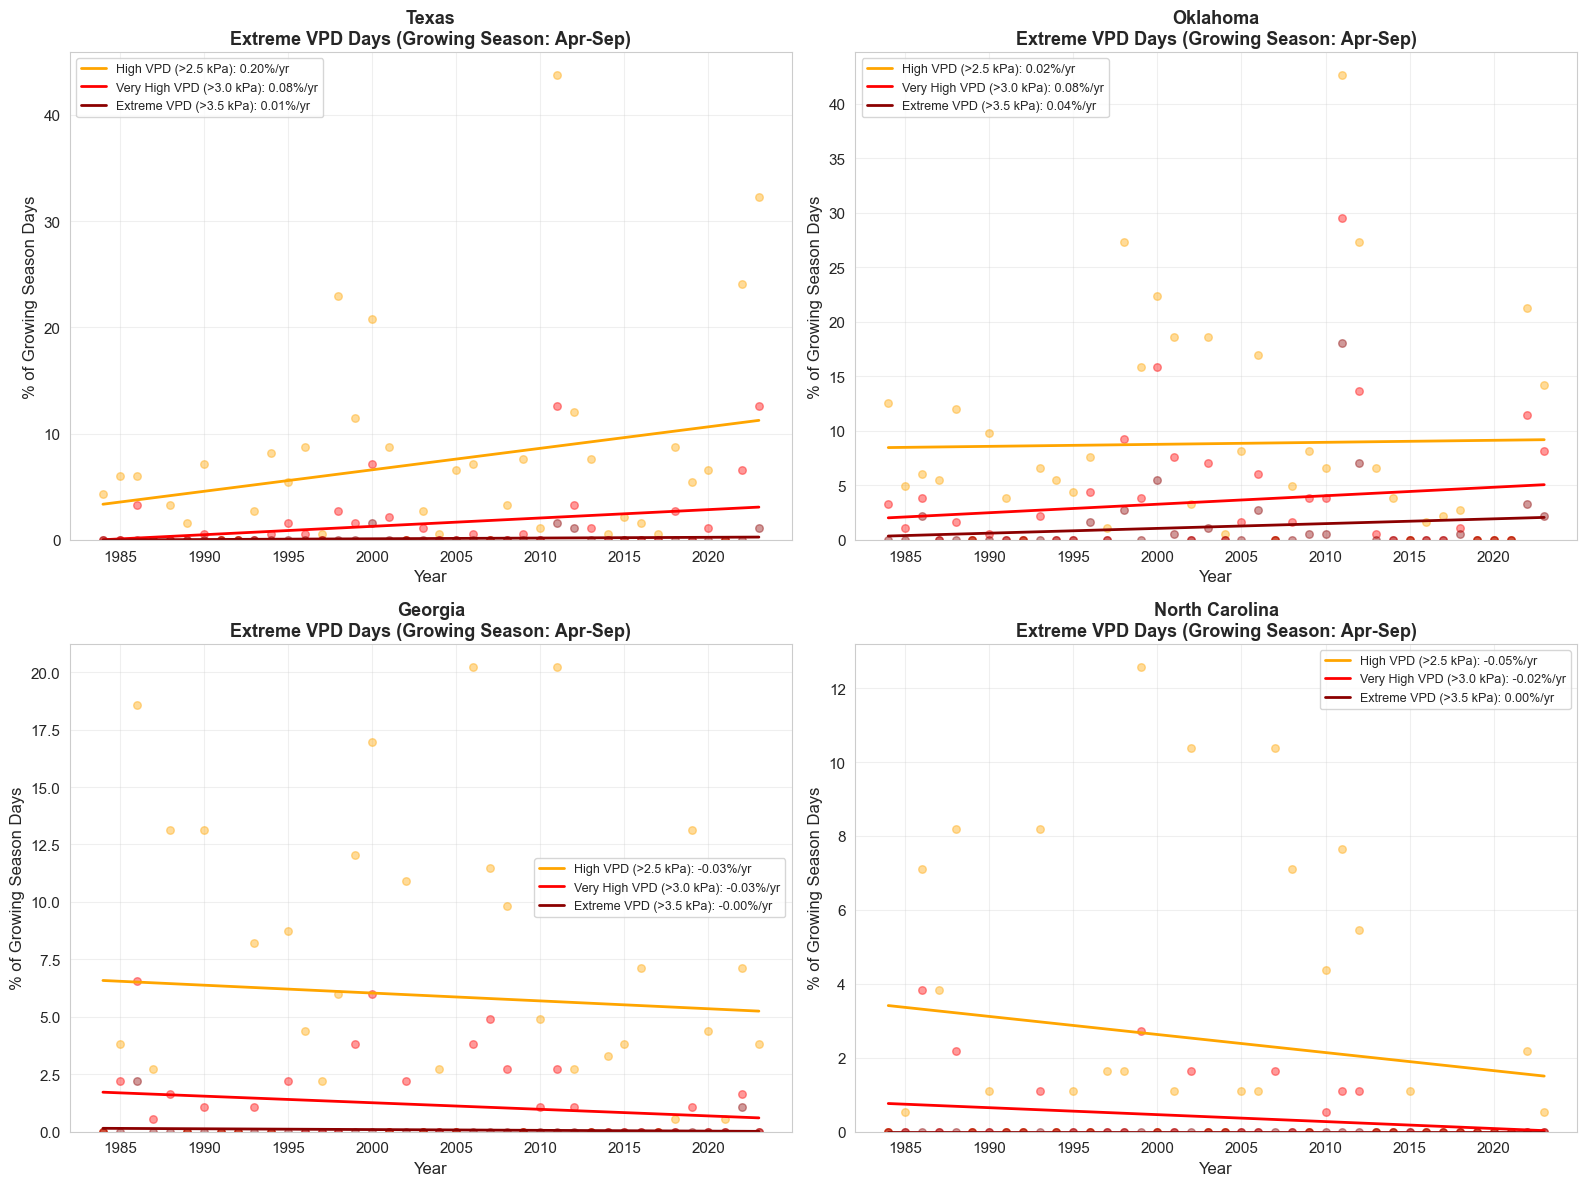

Plot 12 saved!

=== VPD Climate Signal Analysis Complete ===
VPD shows stronger trends than temperature, revealing:
  • Increasing atmospheric dryness (kPa/decade by month)
  • More frequent extreme VPD days (%/year)
  • Amplified stress during growing season


In [17]:
# Extreme VPD days frequency - showing amplification of extremes
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

# Define VPD thresholds
vpd_thresholds = [
    (2.5, 'High VPD (>2.5 kPa)', 'orange'),
    (3.0, 'Very High VPD (>3.0 kPa)', 'red'),
    (3.5, 'Extreme VPD (>3.5 kPa)', 'darkred')
]

for idx, (state_name, state_id) in enumerate(focus_states_vpd.items()):
    ax = axes[idx]
    
    # Compute state mean for VPD
    state_data = compute_state_mean(ds_vpd['vpd_mean'], state_id)
    
    # Filter for growing season (April-September)
    growing_season = state_data.where(state_data.time.dt.month.isin([4, 5, 6, 7, 8, 9]), drop=True)
    
    # Count extreme days by year for each threshold
    for threshold, label, color in vpd_thresholds:
        extreme_days_per_year = []
        years = []
        
        for year in range(1984, 2024):
            year_data = growing_season.where(growing_season.time.dt.year == year, drop=True)
            
            if len(year_data) > 100:  # Need sufficient data
                # Count days exceeding threshold
                n_extreme = (year_data > threshold).sum().values
                total_days = len(year_data)
                pct_extreme = (n_extreme / total_days * 100) if total_days > 0 else 0
                
                extreme_days_per_year.append(float(pct_extreme))
                years.append(year)
        
        if len(years) > 20:
            years = np.array(years)
            extreme_days_per_year = np.array(extreme_days_per_year)
            
            # Plot with trend
            ax.scatter(years, extreme_days_per_year, alpha=0.4, s=30, color=color)
            
            # Add trend line
            z = np.polyfit(years, extreme_days_per_year, 1)
            p = np.poly1d(z)
            ax.plot(years, p(years), '-', linewidth=2, color=color, 
                   label=f'{label}: {z[0]:.2f}%/yr')
    
    ax.set_xlabel('Year')
    ax.set_ylabel('% of Growing Season Days')
    ax.set_title(f'{state_name}\nExtreme VPD Days (Growing Season: Apr-Sep)', fontweight='bold')
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / '12_vpd_extreme_days_frequency.png', dpi=300, bbox_inches='tight')
plt.show()
print("Plot 12 saved!")
print("\n=== VPD Climate Signal Analysis Complete ===")
print("VPD shows stronger trends than temperature, revealing:")
print("  • Increasing atmospheric dryness (kPa/decade by month)")
print("  • More frequent extreme VPD days (%/year)")
print("  • Amplified stress during growing season")

## Summary

This notebook generated 12 comprehensive temporal analysis plots:

1. **Seasonal Cycles** - Typical yearly patterns for each state
2. **Annual Trends** - Long-term climate change signals (1984-2025)
3. **Decadal Boxplots** - Distribution shifts across four decades
4. **Calendar Heatmap** - Daily pattern visualization for recent year
5. **Anomaly Time Series** - Departures from climatology with trends
6. **Seasonal Decomposition** - Trend, seasonal, and residual components
7. **Seasonal State Comparison** - How states differ by season
8. **Inter-annual Variability** - Which metrics show most year-to-year change
9. **Seasonal Expansion Timing** - First and last occurrence of hot nights each year
10. **Monthly Frequency by Decade** - Heatmap of hot night frequency changes
11. **VPD Trends by Month** - Stronger climate signals in atmospheric dryness
12. **Extreme VPD Days Frequency** - Increasing frequency of severe VPD events - Which metrics show most year-to-year change

**Key Insights:**
- Summer heat stress shows increasing trends across most states
- Texas and Oklahoma experience the most extreme heat conditions
- Year-to-year variability is highest for VPD metrics
- Recent decade (2014-2023) shows elevated heat stress vs. 1984-1993